## Comparison of binomial tree and 1D neural network

In [1]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from neural_network.trainer import GeneralTrainer
from neural_network.payoff import Put
from neural_network.config import MarketParams, ModelConfig

from binomial_tree.binomial_tree import BinomialTree

In [2]:
S0 = 1.0
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
bt = BinomialTree(market_params, n_steps=100)

In [4]:
input_size = 2
hidden_sizes = [64, 128, 128, 64]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.0001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
loss_weights = {
    'pde': 10.0,
    'exercise': 2.0,
    'boundary_Smax': 6,
    'boundary_Smin': 1/8
}

In [6]:
put_payoff = Put()
trainer = GeneralTrainer(model_config, market_params, put_payoff, loss_weights=loss_weights, seed=42)
trainer.train(batch_size=1000, epochs=10000, tol=1e-9)

Iteration 0, Loss: 0.6376795768737793
Iteration 100, Loss: 0.14016763865947723
Iteration 200, Loss: 0.0217294879257679
Iteration 300, Loss: 0.006081254221498966
Iteration 400, Loss: 0.003086195094510913
Iteration 500, Loss: 0.001385389594361186
Iteration 600, Loss: 0.0008127850014716387
Iteration 700, Loss: 0.0005257221637293696
Iteration 800, Loss: 0.00036256382009014487
Iteration 900, Loss: 0.00023799101472832263
Iteration 1000, Loss: 0.00010215105430688709
Iteration 1100, Loss: 9.378211689181626e-05
Iteration 1200, Loss: 6.934885459486395e-05
Iteration 1300, Loss: 4.913882730761543e-05
Iteration 1400, Loss: 4.3635267502395436e-05
Iteration 1500, Loss: 3.137789826723747e-05
Iteration 1600, Loss: 2.85351270576939e-05
Iteration 1700, Loss: 2.8803182431147434e-05
Iteration 1800, Loss: 2.7038469852413982e-05
Iteration 1900, Loss: 1.9781347873504274e-05
Iteration 2000, Loss: 2.0342313291621394e-05
Iteration 2100, Loss: 1.67425096151419e-05
Iteration 2200, Loss: 1.904453347378876e-05
Itera

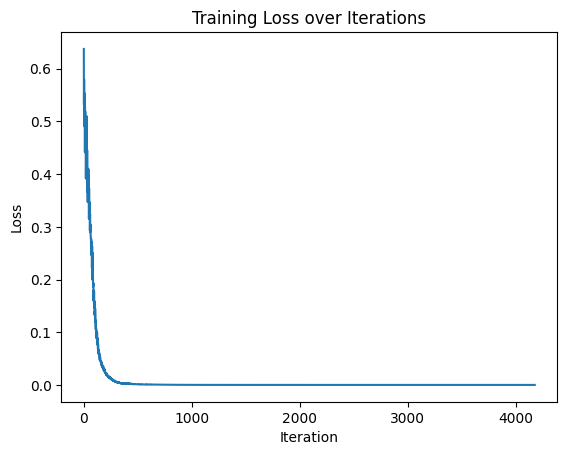

In [7]:
trainer.plot_losses()

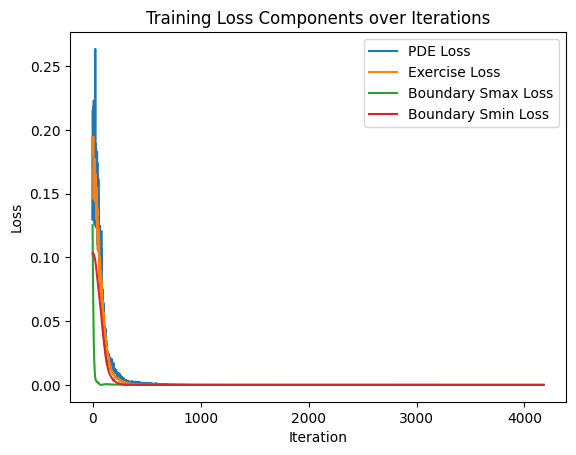

In [8]:
trainer.plot_losses_detailed()

In [9]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_prices[i, j] = bt.predict(t_val, s_val)

/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_32573/3584896141.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_prices[i, j] = bt.predict(t_val, s_val)


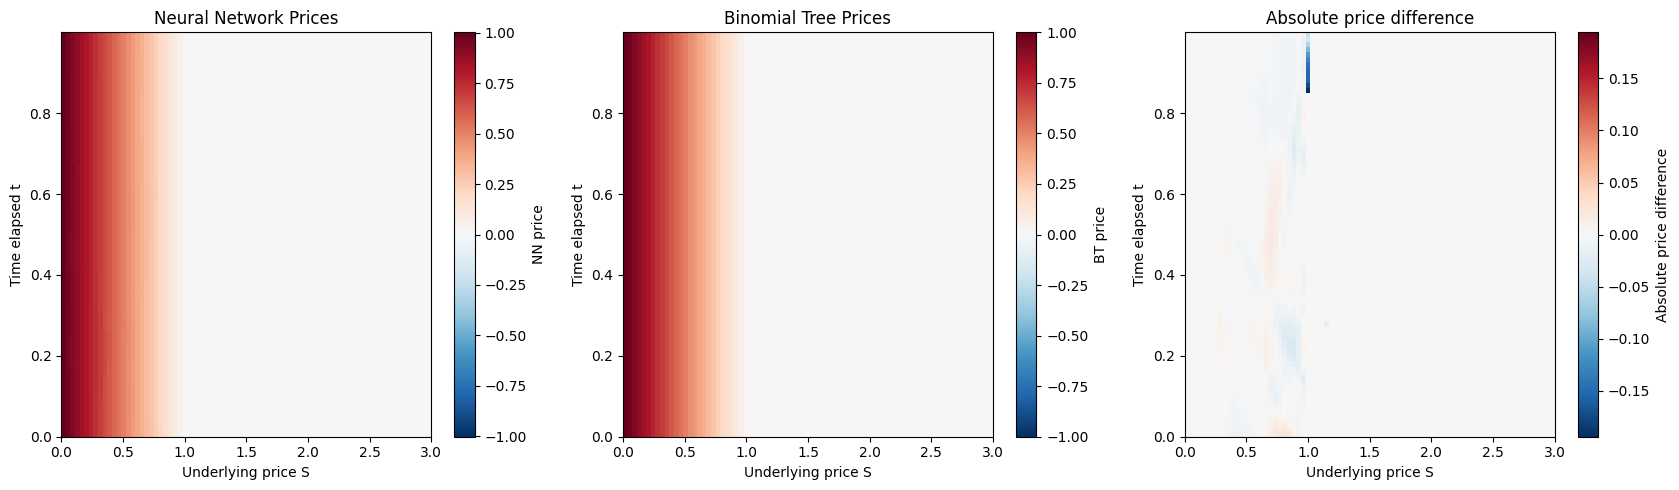

In [15]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
vmax = np.abs(bt_prices).max()
vmin = -vmax
im2 = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='BT price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Binomial Tree Prices')

plt.subplot(1, 3, 3)
# diff = nn_prices - bt_prices
diff = (nn_prices - bt_prices) / np.maximum(bt_prices, 1e-8)
diff = np.where(np.abs(diff) > 0.2, 0.0, diff)  # avoid plotting tiny differences

vmax = np.abs(diff).max()
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Absolute price difference')
plt.tight_layout()
plt.show()

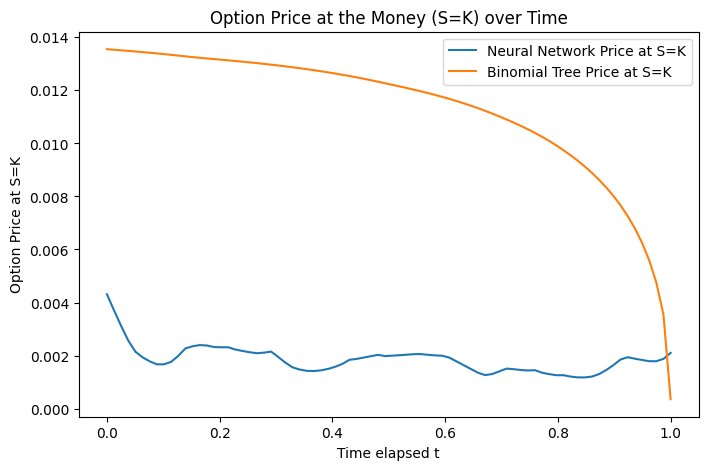

In [11]:
# Error at the money
S_try = K
nn_prices_atm = [trainer.predict(t, S_try).item() for t in Ts]
bt_prices_atm = [bt.predict(t, S_try) for t in Ts]

plt.figure(figsize=(8, 5))
plt.plot(Ts, nn_prices_atm, label='Neural Network Price at S=K')
plt.plot(Ts, bt_prices_atm, label='Binomial Tree Price at S=K')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over Time')
plt.legend()
plt.show()